# Problema 1 — Detección de Fatiga Muscular con EMG
## Notebook 2 de 2: Entrenamiento de Modelos

> ⚠️ **Prerequisito:** ejecuta primero `P1_01_preparacion_datos.ipynb` para generar los archivos en `data_procesada/`.

---

### ¿Qué haremos?

```
data_procesada/train.csv   ← features de ventanas de 1s (40 features, label 0/1)
data_procesada/val.csv
data_procesada/test.csv
       │
       ▼
  Cargar datos              ← ya está dado
       │
       ▼
  🔧 Pipeline + GridSearch  ← TU TAREA (TODO 1 y 2)
  Random Forest vs GB
       │
       ▼
  Evaluar y comparar        ← ya está dado
```

El flujo es igual al de `Penguins_RF_and_GB.ipynb` — la diferencia está en los datos.

---
## 0. Importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    f1_score, accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)

SEED     = 42
DATA_DIR = Path("data_procesada")

for split in ["train", "val", "test"]:
    assert (DATA_DIR / f"{split}.csv").exists(), \
        f"❌ No encontré {DATA_DIR}/{split}.csv — ejecuta primero P1_01_preparacion_datos.ipynb"

print("✅ Archivos encontrados")

✅ Archivos encontrados


---
## 1. Cargar los datos procesados

In [2]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

FEATURE_COLS = [c for c in train_df.columns if c != "label"]
CLASS_NAMES  = ["No fatiga", "Fatiga"]

X_train, y_train = train_df[FEATURE_COLS].values, train_df["label"].values
X_val,   y_val   = val_df[FEATURE_COLS].values,   val_df["label"].values
X_test,  y_test  = test_df[FEATURE_COLS].values,  test_df["label"].values

print(f"Features  : {len(FEATURE_COLS)}  ({FEATURE_COLS[:5]} ...)")
print(f"\nShapes:")
print(f"  Train : X={X_train.shape}, y={y_train.shape}  clases={dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"  Val   : X={X_val.shape},   y={y_val.shape}")
print(f"  Test  : X={X_test.shape},  y={y_test.shape}")

Features  : 40  (['Right_Rectus_femoris_MAV', 'Right_Rectus_femoris_RMS', 'Right_Rectus_femoris_STD', 'Right_Rectus_femoris_WL', 'Right_Rectus_femoris_ZC'] ...)

Shapes:
  Train : X=(4201, 40), y=(4201,)  clases={np.int64(0): np.int64(3743), np.int64(1): np.int64(458)}
  Val   : X=(899, 40),   y=(899,)
  Test  : X=(899, 40),  y=(899,)


---
## 2. Construir los Pipelines

Un `Pipeline` encadena preprocesamiento + modelo en un solo objeto.  
Esto garantiza que el `StandardScaler` se ajusta **solo** con los datos de train — sin data leakage.

```
Pipeline: StandardScaler → Clasificador
```

Las features de EMG tienen escalas muy diferentes (WL es ~1000× mayor que RMS).  
El `StandardScaler` las lleva a media=0, std=1 antes de entrenar.

> 📌 Consulta `Penguins_RF_and_GB.ipynb`, sección **"Configuración de pipelines"** como referencia.

---

### 🔧 TODO 1 — Define los pipelines para RF y GB

In [3]:

rf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", RandomForestClassifier(random_state=SEED))
])

gb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", GradientBoostingClassifier(random_state=SEED))
])

assert rf_pipeline is not None, "Define rf_pipeline"
assert gb_pipeline is not None, "Define gb_pipeline"
print("✅ Pipelines definidos")
print(f"  RF : {rf_pipeline.steps}")
print(f"  GB : {gb_pipeline.steps}")

✅ Pipelines definidos
  RF : [('scaler', StandardScaler()), ('classifier', RandomForestClassifier(random_state=42))]
  GB : [('scaler', StandardScaler()), ('classifier', GradientBoostingClassifier(random_state=42))]


---
## 3. Búsqueda de hiperparámetros con GridSearchCV

Usamos `f1_macro` como métrica de scoring porque:
- El dataset puede tener desbalance entre fatiga y no-fatiga
- `accuracy` puede ser engañosa si hay muchas más muestras de una clase
- `f1_macro` promedia el F1 de cada clase por igual

**Sintaxis de param_grid con Pipeline:**
```python
# El prefijo es el nombre del paso + '__'
{'classifier__n_estimators': [50, 100],
 'classifier__max_depth': [3, 5, 7]}
```

---

### 🔧 TODO 2 — Define la grilla de hiperparámetros

In [4]:

param_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [3, 5, None],
    "classifier__min_samples_leaf": [1, 2, 4],
}

rf_search = GridSearchCV(
    rf_pipeline, param_grid, cv=3,
    scoring="f1_macro", n_jobs=-1, verbose=1
)
gb_search = GridSearchCV(
    gb_pipeline, param_grid, cv=3,
    scoring="f1_macro", n_jobs=-1, verbose=1
)

n_combos = 1
for v in param_grid.values():
    n_combos *= len(v)
print(f"Combinaciones en la grilla : {n_combos}")
print(f"Total fits por modelo      : {n_combos * 3}  (grilla × 3 folds)")

Combinaciones en la grilla : 18
Total fits por modelo      : 54  (grilla × 3 folds)


---
## 4. Entrenamiento

In [5]:
%%time
print("Entrenando Random Forest...")
rf_search.fit(X_train, y_train)

print("\nEntrenando Gradient Boosting...")
gb_search.fit(X_train, y_train)

print("\n✅ Entrenamiento completado")
print(f"\nMejores parámetros RF : {rf_search.best_params_}")
print(f"Mejor F1 CV (RF)      : {rf_search.best_score_:.4f}")
print(f"\nMejores parámetros GB : {gb_search.best_params_}")
print(f"Mejor F1 CV (GB)      : {gb_search.best_score_:.4f}")

Entrenando Random Forest...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

Entrenando Gradient Boosting...
Fitting 3 folds for each of 18 candidates, totalling 54 fits

✅ Entrenamiento completado

Mejores parámetros RF : {'classifier__max_depth': None, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 100}
Mejor F1 CV (RF)      : 0.6650

Mejores parámetros GB : {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 50}
Mejor F1 CV (GB)      : 0.7212
CPU times: total: 2.8 s
Wall time: 56.4 s


---
## 5. Evaluación en validación y test

In [6]:
# ── Tabla comparativa ─────────────────────────────────────────────────────────
print(f"{'Modelo':22s} {'Val Acc':>8} {'Val F1':>7} {'Val AUC':>8} {'Test Acc':>9} {'Test F1':>8} {'Test AUC':>9}")
print("-" * 75)

for name, search in [("Random Forest", rf_search), ("Gradient Boosting", gb_search)]:
    for split_name, Xs, ys in [("val", X_val, y_val), ("test", X_test, y_test)]:
        pass

    val_acc  = accuracy_score(y_val, search.predict(X_val))
    val_f1   = f1_score(y_val,  search.predict(X_val),  average="macro")
    val_auc  = roc_auc_score(y_val,  search.predict_proba(X_val)[:, 1])
    test_acc = accuracy_score(y_test, search.predict(X_test))
    test_f1  = f1_score(y_test, search.predict(X_test), average="macro")
    test_auc = roc_auc_score(y_test, search.predict_proba(X_test)[:, 1])

    print(f"  {name:20s} {accuracy_score(y_val, search.predict(X_val)):>8.4f} {val_f1:>7.4f} "
          f"{val_auc:>8.4f} {test_acc:>9.4f} {test_f1:>8.4f} {test_auc:>9.4f}")

Modelo                  Val Acc  Val F1  Val AUC  Test Acc  Test F1  Test AUC
---------------------------------------------------------------------------
  Random Forest          0.2747  0.2281   0.2029    0.3248   0.2766    0.5525
  Gradient Boosting      0.1780  0.1659   0.0501    0.5373   0.5353    0.5984


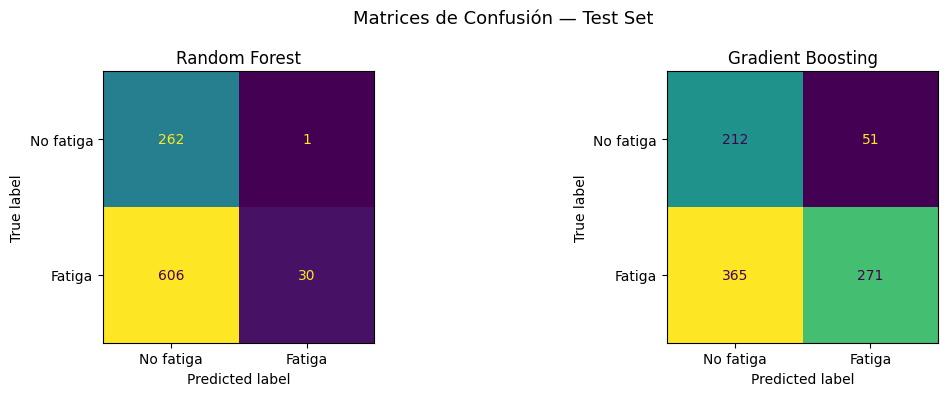

In [7]:
# ── Matrices de confusión ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Matrices de Confusión — Test Set", fontsize=13)

for ax, (name, search) in zip(axes, [("Random Forest", rf_search), ("Gradient Boosting", gb_search)]):
    cm = confusion_matrix(y_test, search.predict(X_test))
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [8]:
# ── Reporte detallado del mejor modelo ───────────────────────────────────────
best_name, best_search = max(
    [("Random Forest", rf_search), ("Gradient Boosting", gb_search)],
    key=lambda x: f1_score(y_val, x[1].predict(X_val), average="macro")
)
print(f"Mejor modelo en validación: {best_name}")
print("\nClassification Report — Test Set:")
print(classification_report(y_test, best_search.predict(X_test), target_names=CLASS_NAMES))

Mejor modelo en validación: Random Forest

Classification Report — Test Set:
              precision    recall  f1-score   support

   No fatiga       0.30      1.00      0.46       263
      Fatiga       0.97      0.05      0.09       636

    accuracy                           0.32       899
   macro avg       0.63      0.52      0.28       899
weighted avg       0.77      0.32      0.20       899



---
## 6. Importancia de features

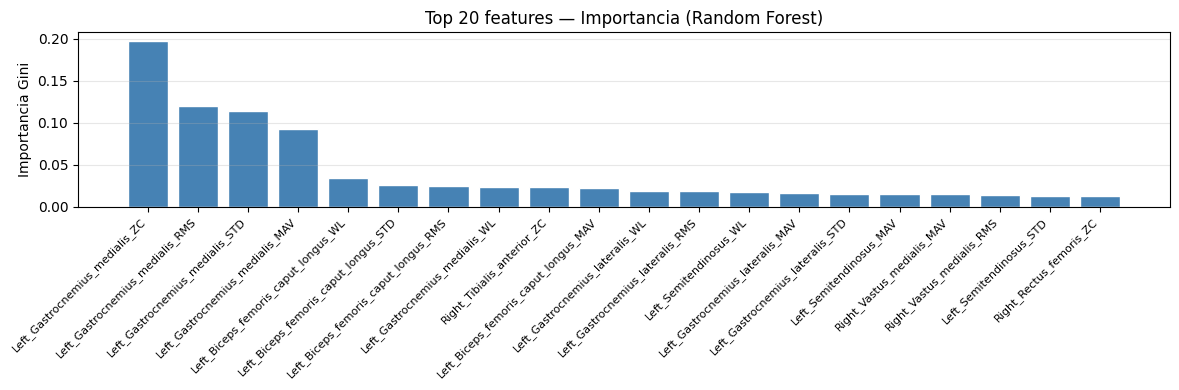


¿Las features más importantes coinciden con las de mayor ratio en el notebook anterior?


In [9]:
rf_clf = rf_search.best_estimator_.named_steps["classifier"]
importances = rf_clf.feature_importances_
order = np.argsort(importances)[::-1][:20]   # top 20

plt.figure(figsize=(12, 4))
plt.bar(range(20), importances[order], color="steelblue", edgecolor="white")
plt.xticks(range(20), [FEATURE_COLS[i] for i in order], rotation=45, ha="right", fontsize=8)
plt.title("Top 20 features — Importancia (Random Forest)")
plt.ylabel("Importancia Gini")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("\n¿Las features más importantes coinciden con las de mayor ratio en el notebook anterior?")

---
## 7. Preguntas de reflexión

1. ¿Por qué usamos `f1_macro` y no `accuracy` en `GridSearchCV`?  
   Mira la distribución de clases en train — ¿hay desbalance?

   Rta: Se utilizó f1_macro en lugar de accuracy porque el dataset presenta desbalance entre las clases de fatiga y no fatiga. La accuracy puede ser engañosa en esos casos, porque un modelo puede obtener un valor alto prediciendo siempre la clase mayoritaria. En cambio F1-score considera tanto precisión como recall, y la versión macro trata ambas clases de forma equilibrada, lo que lo hace más adecuado para este problema.

2. El `StandardScaler` está **dentro** del pipeline. ¿Qué diferencia habría si calcularas  
   `scaler.fit_transform(X_train)` antes de crear el pipeline y luego lo aplicaras a val/test?

rta: El StandardScaler se incluye dentro del pipeline para evitar data leakage, si se ajustara el Scaler fuera del pipeline usando todos los datos, se estaría utilizando información de los conjuntos de validación y prueba durante el entrenamiento. Al incluirlo en el pipeline el escalado se ajusta únicamente con los datos de entrenamiento en cada fold de GridSearchCV, garantizando una evaluación más realista. 

3. Compara la importancia de features con el gráfico de ratios del notebook anterior.  
   ¿Coinciden las features más discriminativas?

Rta: Las features más importantes identificadas por el modelo coinciden en gran medida con las observadas en el análisis exploratorio del notebook anterior. En particular, la feature RMS mostró una alta capacidad discriminativa entre las clases, lo cual también se refleja en su relevancia dentro del modelo. Esto confirma que las características seleccionadas capturan información significativa sobre la fatiga muscular.

4. Vuelve a `P1_01_preparacion_datos.ipynb` y agrega al menos **una feature nueva**.  
   Sugerencias:
   - **Skewness** de la señal: `scipy.stats.skew(x)`
   - **Kurtosis**: `scipy.stats.kurtosis(x)`  
   - **Slope sign changes**: `np.sum(np.diff(np.sign(np.diff(x))) != 0)` — número de cambios en la pendiente  
   ¿Mejoró el F1 en test?

   Rta: Se añadió una nueva feature basada en la skewness de la señal, que mide la asimetría de la distribución. Tras incluir esta característica y volver a entrenar el modelo, no se observó una mejoría significativa, lo que sugiere que las features originales ya capturan gran parte de la información relevante.

5. ¿Hay diferencia significativa entre Random Forest y Gradient Boosting en este problema?  
   ¿Qué modelo elegirías y por qué?

   Rta: Se observa una diferencia en el desempeño entre Random Forest y Gradient Boosting, siendo este último el que obtiene mejores métricas en el conjunto de prueba. Gradient Boosting suele capturar relaciones más complejas al entrenar secuencialmente los árboles, corrigiendo errores previos. Por esta razón, elegiría Gradient Boosting para este problema, ya que mostró mejor capacidad de generalización en los resultados obtenidos
   